# Xem nhanh dữ liệu giá vé máy bay

File gốc `itineraries.csv` nặng **31 GB (~82 triệu dòng)**, Excel và Notepad không mở được.
Notebook này dùng file mẫu **~100.000 dòng** lấy đều từ toàn bộ file gốc (tạo bằng `make_samples.py`).

**Cách chạy:** bấm *Run All* ở thanh trên cùng (lần đầu VS Code hỏi chọn kernel → chọn **Python 3.12**).

| Cột | Ý nghĩa |
|---|---|
| `legId` | mã định danh của hành trình bay |
| `searchDate` | ngày người dùng tìm vé trên Expedia |
| `flightDate` | ngày bay |
| `startingAirport`, `destinationAirport` | mã sân bay đi / đến (IATA) |
| `fareBasisCode` | mã hạng giá vé |
| `travelDuration` | tổng thời gian hành trình, dạng ISO 8601 (`PT2H29M` = 2 giờ 29 phút) |
| `elapsedDays` | số ngày qua đêm trong hành trình |
| `isBasicEconomy`, `isRefundable`, `isNonStop` | vé phổ thông cơ bản / được hoàn tiền / bay thẳng |
| `baseFare`, `totalFare` | giá gốc và giá đã gồm thuế phí (USD) |
| `seatsRemaining` | số ghế còn lại ở mức giá đó |
| `totalTravelDistance` | tổng quãng đường (dặm) |
| `segments...` | thông tin từng chặng bay, các chặng nối với nhau bằng `\|\|` |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DATA_DIR = "D:/TH-PTDLL/data/flightprices"
df = pd.read_csv(f"{DATA_DIR}/itineraries_sample_100k.csv", parse_dates=["searchDate", "flightDate"])
print("Số dòng, số cột:", df.shape)
df.head(10)

Số dòng, số cột: (100170, 27)


,legId,searchDate,flightDate,startingAirport,destinationAirport,fareBasisCode,travelDuration,elapsedDays,isBasicEconomy,isRefundable,isNonStop,baseFare,totalFare,seatsRemaining,totalTravelDistance,segmentsDepartureTimeEpochSeconds,segmentsDepartureTimeRaw,segmentsArrivalTimeEpochSeconds,segmentsArrivalTimeRaw,segmentsArrivalAirportCode,segmentsDepartureAirportCode,segmentsAirlineName,segmentsAirlineCode,segmentsEquipmentDescription,segmentsDurationInSeconds,segmentsDistance,segmentsCabinCode
0,9ca0e81111c683bec1012473feefd28f,2022-04-16,2022-04-17,ATL,BOS,LA0NX0MC,PT2H29M,0,False,False,True,217.67,248.60,9,947.0,1650214620,2022-04-17T12:57:00.000-04:00,1650223560,2022-04-17T15:26:00.000-04:00,BOS,ATL,Delta,DL,Airbus A321,8940,947,coach
1,3af877dc5b27e0f89df5e480166a0e40,2022-04-16,2022-04-17,BOS,MIA,HNR,PT7H5M,0,False,False,False,260.00,367.58,0,NaN,1650210900||1650232500,2022-04-17T11:55:00.000-04:00||2022-04-17T17:5...,1650222480||1650236400,2022-04-17T15:08:00.000-04:00||2022-04-17T19:0...,MCO||MIA,BOS||MCO,Spirit Airlines||Spirit Airlines,NK||NK,||AIRBUS INDUSTRIE A321 SHARKLETS,11580||3900,None||None,coach||coach
2,c49e52befabd64a8d6a6ded040017717,2022-04-16,2022-04-17,DEN,CLT,QAA0KKEN,PT7H2M,0,False,False,False,296.74,342.60,1,2166.0,1650196800||1650215100,2022-04-17T06:00:00.000-06:00||2022-04-17T13:0...,1650209820||1650222120,2022-04-17T11:37:00.000-04:00||2022-04-17T15:0...,EWR||CLT,DEN||EWR,United||United,UA||UA,Airbus A319||,13020||7020,1621||545,coach||coach
3,51d2a7ab3fdc616a111858f52288c072,2022-04-16,2022-04-17,DFW,MIA,BA0OA0MC,PT6H16M,0,False,False,False,600.00,668.60,9,1321.0,1650201600||1650217620,2022-04-17T08:20:00.000-05:00||2022-04-17T13:4...,1650208980||1650224160,2022-04-17T11:23:00.000-04:00||2022-04-17T15:3...,ATL||MIA,DFW||ATL,Delta||Delta,DL||DL,Airbus A321||Airbus A321,7380||6540,725||596,coach||coach
4,3c788344ccbdbeefbbad40b0fd3aaaf4,2022-04-16,2022-04-17,EWR,DEN,HAA0AFEN,PT8H1M,0,False,False,False,366.51,417.60,5,2295.0,1650197700||1650217200,2022-04-17T08:15:00.000-04:00||2022-04-17T12:4...,1650211500||1650226560,2022-04-17T11:05:00.000-05:00||2022-04-17T14:1...,IAH||DEN,EWR||IAH,United||United,UA||UA,BOEING 777-300ER||Boeing 737 MAX 9,13800||9360,1419||876,coach||coach
5,d5b130c87aeb23864e9278552abf94cc,2022-04-16,2022-04-17,JFK,DTW,HH0ABEY5,PT2H8M,0,False,False,True,240.93,273.60,7,485.0,1650246600,2022-04-17T21:50:00.000-04:00,1650254280,2022-04-17T23:58:00.000-04:00,DTW,JFK,American Airlines,AA,Embraer 190,7680,485,coach
6,ccb70b8fa2121bd75d7b1ad383bdd0f2,2022-04-16,2022-04-17,LAX,LGA,VAA0KKEN,PT8H55M,0,False,False,False,322.79,370.60,9,2469.0,1650210900||1650229500,2022-04-17T08:55:00.000-07:00||2022-04-17T15:0...,1650219300||1650243000,2022-04-17T12:15:00.000-06:00||2022-04-17T20:5...,DEN||LGA,LAX||DEN,United||United,UA||UA,Boeing 737 MAX 9||Airbus A319,8400||13500,848||1621,coach||coach
7,45421ee8e2949f14c693dbc1edca8bbc,2022-04-16,2022-04-17,MIA,DTW,BA0OA0MQ,PT2H57M,0,False,False,True,580.47,638.61,1,1153.0,1650214320,2022-04-17T12:52:00.000-04:00,1650224940,2022-04-17T15:49:00.000-04:00,DTW,MIA,Delta,DL,Airbus A321,10620,1153,coach
8,15106434f8df087db90368558f65ada1,2022-04-16,2022-04-17,ORD,EWR,G0AZZNN1,PT2H1M,0,False,False,True,141.40,166.61,7,720.0,1650236340,2022-04-17T17:59:00.000-05:00,1650243600,2022-04-17T21:00:00.000-04:00,EWR,ORD,American Airlines,AA,Boeing 737-800,7260,720,coach
9,8397f0f4b589d535e348e317e83e08ca,2022-04-16,2022-04-17,PHL,LGA,G0AIZNN1,PT10H35M,0,False,False,False,328.38,382.21,7,1392.0,1650189600||1650220200,2022-04-17T06:00:00.000-04:00||2022-04-17T13:3...,1650198600||1650227700,2022-04-17T07:30:00.000-05:00||2022-04-17T16:3...,ORD||LGA,PHL||ORD,American Airlines||American Airlines,AA||AA,Boeing 737-800||Boeing 737-800,9000||7500,672||720,coach||coach


## Kiểu dữ liệu và số giá trị bị thiếu của từng cột

In [2]:
pd.DataFrame({
    "kiểu": df.dtypes.astype(str),
    "số ô trống": df.isna().sum(),
    "ví dụ": df.iloc[0],
})

,kiểu,số ô trống,ví dụ
legId,str,0,9ca0e81111c683bec1012473feefd28f
searchDate,datetime64[us],0,2022-04-16 00:00:00
flightDate,datetime64[us],0,2022-04-17 00:00:00
startingAirport,str,0,ATL
destinationAirport,str,0,BOS
fareBasisCode,str,0,LA0NX0MC
travelDuration,str,0,PT2H29M
elapsedDays,int64,0,0
isBasicEconomy,bool,0,False
isRefundable,bool,0,False


## Thống kê các cột số

In [3]:
df[["baseFare", "totalFare", "seatsRemaining", "totalTravelDistance", "elapsedDays"]].describe().round(2)

,baseFare,totalFare,seatsRemaining,totalTravelDistance,elapsedDays
count,100170.00,100170.00,100170.00,92578.00,100170.00
mean,291.84,339.55,5.97,1609.39,0.15
std,182.52,195.25,2.89,857.56,0.36
min,0.01,19.59,0.00,89.00,0.00
25%,158.00,197.10,4.00,876.00,0.00
50%,260.47,304.61,7.00,1462.00,0.00
75%,395.35,450.60,9.00,2415.00,0.00
max,4407.44,4752.60,10.00,4498.00,1.00


## Khoảng thời gian, sân bay và hãng bay

In [4]:
print("Ngày tìm vé:", df["searchDate"].min().date(), "→", df["searchDate"].max().date())
print("Ngày bay:   ", df["flightDate"].min().date(), "→", df["flightDate"].max().date())
print("Sân bay đi: ", sorted(df["startingAirport"].unique()))
print()
airline = df["segmentsAirlineName"].str.split(r"\|\|").str[0]
print("Số vé theo hãng bay (chặng đầu):")
print(airline.value_counts().to_string())

Ngày tìm vé: 2022-04-16 → 2022-10-05
Ngày bay:    2022-04-17 → 2022-11-19
Sân bay đi:  ['ATL', 'BOS', 'CLT', 'DEN', 'DFW', 'DTW', 'EWR', 'IAD', 'JFK', 'LAX', 'LGA', 'MIA', 'OAK', 'ORD', 'PHL', 'SFO']

Số vé theo hãng bay (chặng đầu):
segmentsAirlineName
American Airlines           30508
Delta                       24776
United                      23203
JetBlue Airways              8445
Spirit Airlines              6414
Alaska Airlines              4963
Frontier Airlines            1384
Sun Country Airlines          304
Cape Air                       60
Southern Airways Express       53
Key Lime Air                   36
Boutique Air                   23
Contour Airlines                1


## Vài biểu đồ đầu tiên

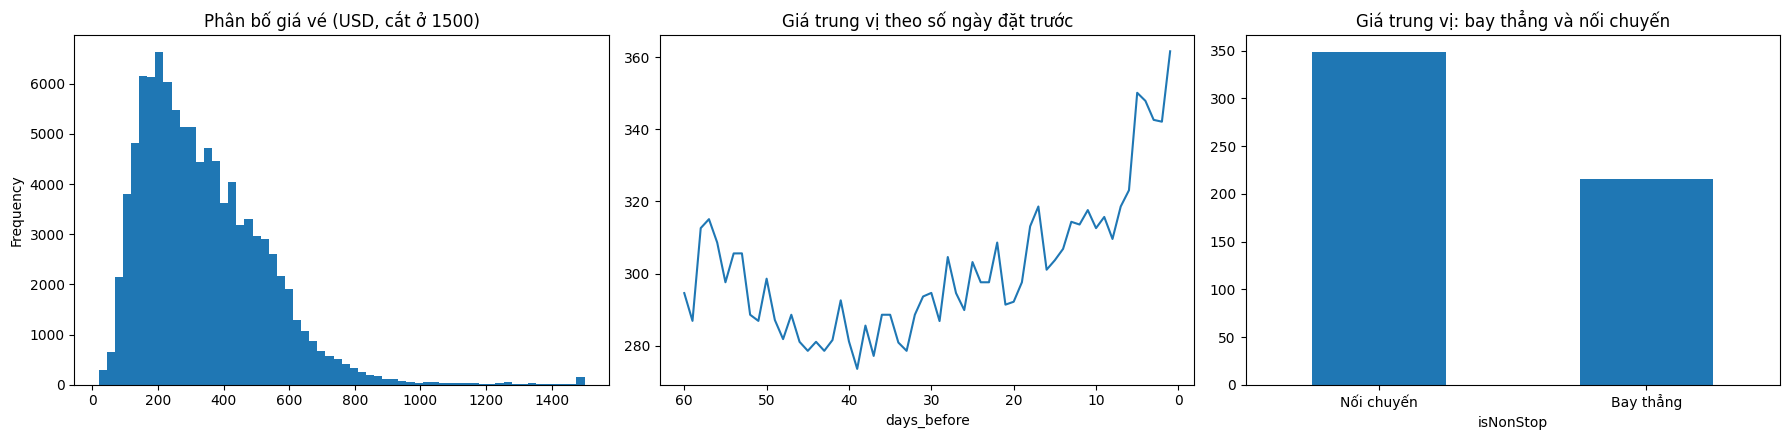

In [5]:
df["days_before"] = (df["flightDate"] - df["searchDate"]).dt.days

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
df["totalFare"].clip(upper=1500).plot.hist(bins=60, ax=axes[0], title="Phân bố giá vé (USD, cắt ở 1500)")
df.groupby("days_before")["totalFare"].median().plot(ax=axes[1], title="Giá trung vị theo số ngày đặt trước")
axes[1].invert_xaxis()
df.groupby("isNonStop")["totalFare"].median().rename({False: "Nối chuyến", True: "Bay thẳng"}) \
  .plot.bar(ax=axes[2], title="Giá trung vị: bay thẳng và nối chuyến", rot=0)
plt.tight_layout()
plt.show()

## Muốn xem thêm từ file gốc 31 GB?

Đọc một phần nhỏ bằng `nrows` (chỉ đọc vài nghìn dòng đầu, không tải cả file vào RAM):

In [6]:
pd.read_csv(f"{DATA_DIR}/itineraries.csv", nrows=5000).tail()

,legId,searchDate,flightDate,startingAirport,destinationAirport,fareBasisCode,travelDuration,elapsedDays,isBasicEconomy,isRefundable,isNonStop,baseFare,totalFare,seatsRemaining,totalTravelDistance,segmentsDepartureTimeEpochSeconds,segmentsDepartureTimeRaw,segmentsArrivalTimeEpochSeconds,segmentsArrivalTimeRaw,segmentsArrivalAirportCode,segmentsDepartureAirportCode,segmentsAirlineName,segmentsAirlineCode,segmentsEquipmentDescription,segmentsDurationInSeconds,segmentsDistance,segmentsCabinCode
4995,a20a8c9f31b818bdb87f955fd38d5e63,2022-04-16,2022-04-17,LAX,MIA,M0CXNR,PT10H51M,1,False,False,False,254.00,361.58,0,NaN,1650259500||1650287400,2022-04-17T22:25:00.000-07:00||2022-04-18T09:1...,1650275100||1650298560,2022-04-18T05:45:00.000-04:00||2022-04-18T12:1...,DTW||MIA,LAX||DTW,Spirit Airlines||Spirit Airlines,NK||NK,Airbus A319||AIRBUS INDUSTRIE A321 SHARKLETS,15600||11160,None||None,coach||coach
4996,c9030c8507635294c9716c742ee7388c,2022-04-16,2022-04-17,LAX,MIA,M0CXNR,PT12H59M,1,False,False,False,254.00,361.58,0,NaN,1650245760||1650283500,2022-04-17T18:36:00.000-07:00||2022-04-18T07:0...,1650256920||1650292500,2022-04-17T23:42:00.000-05:00||2022-04-18T10:3...,IAH||MIA,LAX||IAH,Spirit Airlines||Spirit Airlines,NK||NK,||,11160||9000,None||None,coach||coach
4997,3b14b5694f3e1c3fab9bec04cebf5fc9,2022-04-16,2022-04-17,LAX,MIA,M0CXNR,PT13H42M,1,False,False,False,254.00,361.58,0,NaN,1650261000||1650303600,2022-04-17T22:50:00.000-07:00||2022-04-18T13:4...,1650275640||1650310320,2022-04-18T05:54:00.000-04:00||2022-04-18T15:3...,ATL||MIA,LAX||ATL,Spirit Airlines||Spirit Airlines,NK||NK,AIRBUS INDUSTRIE A320 SHARKLETS||AIRBUS INDUST...,14640||6720,None||None,coach||coach
4998,9a1090917a1b7bd26d3c5c48cf9f5ae7,2022-04-16,2022-04-17,LAX,MIA,MA0NA0MC,PT7H27M,1,False,False,False,322.79,370.60,3,2660.0,1650228000||1650238560,2022-04-17T13:40:00.000-07:00||2022-04-17T17:3...,1650234240||1650254820,2022-04-17T16:24:00.000-06:00||2022-04-18T00:0...,SLC||MIA,ONT||SLC,Delta||Delta,DL||DL,Boeing 737-800||Boeing 737-900,6240||16260,574||2086,coach||coach
4999,9ab78ba5fb124e31a5c13f04236765db,2022-04-16,2022-04-17,LAX,MIA,MA0NA0MC,PT8H32M,1,False,False,False,322.79,370.60,1,2515.0,1650225600||1650249600,2022-04-17T13:00:00.000-07:00||2022-04-17T22:4...,1650239820||1650256320,2022-04-17T19:57:00.000-04:00||2022-04-18T00:3...,ATL||MIA,ONT||ATL,Delta||Delta,DL||DL,Airbus A321||Airbus A321,14220||6720,1919||596,coach||coach
